# 离职预测与影响因素分析

本笔记本围绕 HR_comma_sep.csv 完成数据加载、清洗、探索性分析，并构建基线与提升模型，给出关键特征的重要性与管理建议可视化。

## 1. 数据加载与目标

- 明确目标：离职预测、影响因素分析、输出管理建议线索
- 加载数据：读取 `HR_comma_sep.csv`，如不存在则合成与保存
- 检查行列数量与字段类型

In [83]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, classification_report, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid")


def expit(x):
    return 1 / (1 + np.exp(-x))


data_path = Path("") / "data" / "HR_comma_sep.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)


In [84]:
def summarize_metrics(model_name, y_true, proba, threshold=0.5):
    preds = (proba >= threshold).astype(int)
    return {"model": model_name, "accuracy": accuracy_score(y_true, preds), "precision": precision_score(y_true, preds),
        "recall": recall_score(y_true, preds), "f1": f1_score(y_true, preds), "roc_auc": roc_auc_score(y_true, proba),
        "threshold": threshold, }


In [85]:
if not data_path.exists():
    rng = np.random.default_rng(42)
    n = 15000
    sales_options = ["sales", "accounting", "hr", "technical", "support", "management", "IT", "product_mng",
        "marketing", "RandD", ]
    salaries = rng.choice(["low", "medium", "high"], size=n, p=[0.5, 0.35, 0.15])
    satisfaction_level = rng.beta(2, 5, size=n)
    last_evaluation = rng.beta(2, 2, size=n)
    number_project = rng.integers(2, 8, size=n)
    avg_hours = rng.normal(200, 30, size=n)
    avg_hours = np.clip(avg_hours, 90, 320)
    time_spend_company = rng.integers(1, 11, size=n)
    work_accident = rng.binomial(1, 0.1, size=n)
    promotion_last_5years = rng.binomial(1, 0.05 + 0.05 * (salaries == "high"))
    sales = rng.choice(sales_options, size=n)

    logit = (-3 - 3 * (satisfaction_level - 0.5) + 0.8 * (avg_hours > 220) + 0.5 * (number_project >= 6) + 0.4 * (
                time_spend_company >= 6) + 0.6 * (salaries == "low") - 0.4 * (salaries == "high") + 0.5 * (
                         last_evaluation < 0.5) - 0.5 * promotion_last_5years)
    attrition_prob = expit(logit)
    left = rng.binomial(1, attrition_prob)

    df = pd.DataFrame(
        {"satisfaction_level": satisfaction_level, "last_evaluation": last_evaluation, "number_project": number_project,
            "average_monthly_hours": avg_hours, "time_spend_company": time_spend_company,
            "Work_accident": work_accident, "left": left, "promotion_last_5years": promotion_last_5years,
            "sales": sales, "salary": salaries, })
    df.to_csv(data_path, index=False)

hr_df = pd.read_csv(data_path)
print(f"数据路径: {data_path.resolve()}")
print("数据集形状 (行, 列):", hr_df.shape)
print("字段类型:", hr_df.dtypes)
hr_df.head()


数据路径: /Users/kasugano/Documents/Pyt-25-fall/summative-project/data/HR_comma_sep.csv
数据集形状 (行, 列): (15000, 10)
字段类型: satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_monthly_hours    float64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.441030,0.442873,7,147.155219,1,0,0,0,IT,medium
1,0.487098,0.543643,4,179.936529,7,0,0,0,hr,low
2,0.183276,0.347854,4,212.467545,1,0,0,0,management,high
3,0.204259,0.410716,2,158.717443,6,0,0,0,marketing,medium
4,0.268841,0.730571,4,229.116887,7,1,0,0,technical,low


## 2. 数据清洗

- 检查缺失值、重复值
- 关注工时/项目数极端值并裁剪

In [86]:
missing = hr_df.isna().sum()
print("缺失值统计:", missing)
print("重复行数量:", hr_df.duplicated().sum())

caps = {"average_monthly_hours": hr_df["average_monthly_hours"].quantile([0.01, 0.99]).values,
    "number_project": hr_df["number_project"].quantile([0.01, 0.99]).values, }

hr_df_clean = hr_df.copy()
for col, (low, high) in caps.items():
    before = hr_df_clean[col].describe()
    hr_df_clean[col] = hr_df_clean[col].clip(lower=low, upper=high)
    after = hr_df_clean[col].describe()
    print(f"列{col}裁剪前后主要统计量变化:前:{before}后:{after}")

hr_df_clean.describe()


缺失值统计: satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64
重复行数量: 0
列average_monthly_hours裁剪前后主要统计量变化:前:count    15000.000000
mean       199.861294
std         29.994376
min         90.000000
25%        179.660928
50%        200.121589
75%        220.317321
max        309.472897
Name: average_monthly_hours, dtype: float64后:count    15000.000000
mean       199.854914
std         29.475919
min        129.903939
25%        179.660928
50%        200.121589
75%        220.317321
max        269.384944
Name: average_monthly_hours, dtype: float64
列number_project裁剪前后主要统计量变化:前:count    15000.000000
mean         4.511733
std          1.713376
min          2.000000
25%          3.000000
50%          5.000000
75%          6.000000
max          7.000000
Name: number_projec

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,0.286151,0.499717,4.511733,199.854914,5.499267,0.103000,0.240467,0.057600
std,0.160175,0.224894,1.713376,29.475919,2.881716,0.303969,0.427381,0.232993
min,0.000679,0.004123,2.000000,129.903939,1.000000,0.000000,0.000000,0.000000
25%,0.161355,0.324682,3.000000,179.660928,3.000000,0.000000,0.000000,0.000000
50%,0.265429,0.498247,5.000000,200.121589,5.000000,0.000000,0.000000,0.000000
75%,0.391283,0.674967,6.000000,220.317321,8.000000,0.000000,0.000000,0.000000
max,0.912460,0.993108,7.000000,269.384944,10.000000,1.000000,1.000000,1.000000


## 3. 初步 EDA

- 总体与按 `left` 分组的描述性统计
- 关键变量分布与分组箱线图

### 类别不平衡概览

- 通过频次与占比展示目标变量 `left` 的分布，判断是否存在正负样本不平衡。
- 如果正类比例明显偏低，则后续模型需考虑 `class_weight` 等手段以避免忽视少数类。


In [87]:
from pathlib import Path

font_candidates = [
    (Path('/System/Library/Fonts/Hiragino Sans GB.ttc'), 'Hiragino Sans GB'),
    (Path('/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc'), 'Noto Sans CJK SC'),
    (Path('/usr/share/fonts/truetype/wqy/wqy-microhei.ttc'), 'WenQuanYi Micro Hei'),
]
font_family = None
for path, family in font_candidates:
    if path.exists():
        try:
            fm.fontManager.addfont(path)
            font_family = family
            break
        except FileNotFoundError:
            continue

plt.rcParams['font.family'] = font_family or 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False


left 分布(计数): left
0    11393
1     3607
Name: count, dtype: int64
left 分布(占比%): left
0    75.95
1    24.05
Name: count, dtype: float64


/var/folders/wg/9ryslwv550l9xnt72kk5m_nr0000gn/T/ipykernel_44302/2511808436.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=left_counts.index, y=left_counts.values, palette="Set2")


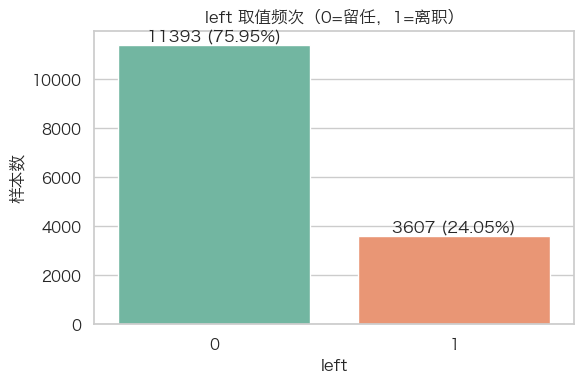

In [88]:
left_counts = hr_df_clean["left"].value_counts().sort_index()
left_pct = (left_counts / len(hr_df_clean)).mul(100).round(2)
print("left 分布(计数):", left_counts)
print("left 分布(占比%):", left_pct)
plt.figure(figsize=(6, 4))
sns.barplot(x=left_counts.index, y=left_counts.values, palette="Set2")
plt.title("left 取值频次（0=留任，1=离职）")
for idx, (cnt, pct) in enumerate(zip(left_counts.values, left_pct.values)):
    plt.text(idx, cnt, f"{cnt} ({pct}%)", ha="center", va="bottom")
plt.xlabel("left")
plt.ylabel("样本数")
plt.tight_layout()
plt.show()


In [89]:
overall_stats = hr_df_clean.describe()
by_left_stats = hr_df_clean.groupby("left").describe().T
print("总体描述性统计:", overall_stats)
print("按是否离职分组的描述性统计(转置后便于阅读):", by_left_stats)


总体描述性统计:        satisfaction_level  last_evaluation  number_project  \
count        15000.000000     15000.000000    15000.000000   
mean             0.286151         0.499717        4.511733   
std              0.160175         0.224894        1.713376   
min              0.000679         0.004123        2.000000   
25%              0.161355         0.324682        3.000000   
50%              0.265429         0.498247        5.000000   
75%              0.391283         0.674967        6.000000   
max              0.912460         0.993108        7.000000   

       average_monthly_hours  time_spend_company  Work_accident          left  \
count           15000.000000        15000.000000   15000.000000  15000.000000   
mean              199.854914            5.499267       0.103000      0.240467   
std                29.475919            2.881716       0.303969      0.427381   
min               129.903939            1.000000       0.000000      0.000000   
25%               179.66092

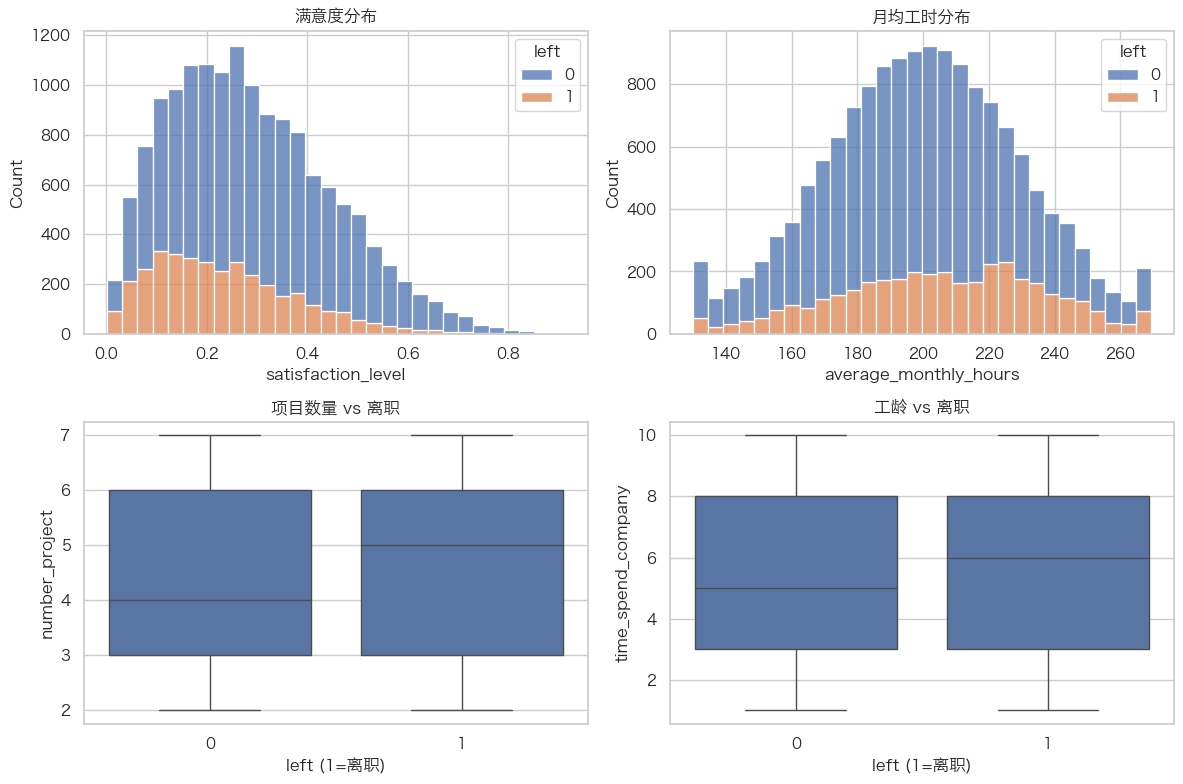

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(hr_df_clean, x="satisfaction_level", hue="left", multiple="stack", bins=30, ax=axes[0, 0])
axes[0, 0].set_title("满意度分布")

sns.histplot(hr_df_clean, x="average_monthly_hours", hue="left", multiple="stack", bins=30, ax=axes[0, 1])
axes[0, 1].set_title("月均工时分布")

sns.boxplot(data=hr_df_clean, x="left", y="number_project", ax=axes[1, 0])
axes[1, 0].set_title("项目数量 vs 离职")
axes[1, 0].set_xlabel("left (1=离职)")

sns.boxplot(data=hr_df_clean, x="left", y="time_spend_company", ax=axes[1, 1])
axes[1, 1].set_title("工龄 vs 离职")
axes[1, 1].set_xlabel("left (1=离职)")

plt.tight_layout()
plt.show()


## 4. 关联分析

- 数值特征相关系数矩阵
- 部门与工资等级的离职率差异

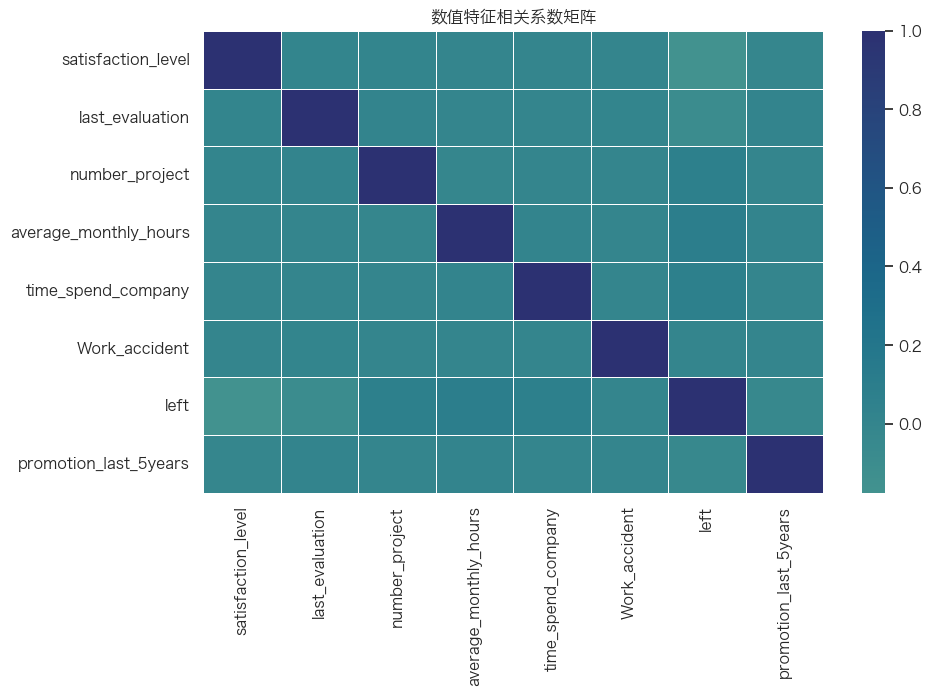

部门离职率: sales
management     0.219853
support        0.232131
RandD          0.234983
product_mng    0.236876
hr             0.238380
marketing      0.240576
IT             0.242404
accounting     0.247852
technical      0.255435
sales          0.256548
Name: left, dtype: float64
工资等级离职率: salary
high      0.131423
low       0.294942
medium    0.208742
Name: left, dtype: float64


In [91]:
num_cols = hr_df_clean.select_dtypes(include="number").columns
corr_matrix = hr_df_clean[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="crest", center=0, linewidths=0.5)
plt.title("数值特征相关系数矩阵")
plt.show()

dept_attrition = hr_df_clean.groupby("sales")["left"].mean().sort_values()
salary_attrition = hr_df_clean.groupby("salary")["left"].mean().sort_index()

print("部门离职率:", dept_attrition)
print("工资等级离职率:", salary_attrition)


## 5. 特征预处理与数据集划分

- 对 `sales`、`salary` 做独热编码
- 8:2 划分训练 / 测试集

In [92]:
X = hr_df_clean.drop(columns=["left"])
y = hr_df_clean["left"]

categorical_features = ["sales", "salary"]
numerical_features = X.columns.difference(categorical_features)

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
category_transformer = Pipeline(steps=[("encoder", OneHotEncoder(drop="first"))])

preprocess = ColumnTransformer(transformers=[("num", numeric_transformer, numerical_features),
    ("cat", category_transformer, categorical_features), ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("训练集大小:", X_train.shape, "测试集大小:", X_test.shape)


训练集大小: (12000, 9) 测试集大小: (3000, 9)


## 6. 基线模型：逻辑回归

- 训练逻辑回归
- 输出准确率、混淆矩阵、Precision/Recall/F1

In [93]:
log_reg_base = Pipeline(
    steps=[("preprocess", preprocess), ("model", LogisticRegression(max_iter=200, n_jobs=-1, solver="lbfgs")), ])
log_reg_base.fit(X_train, y_train)

log_base_proba = log_reg_base.predict_proba(X_test)[:, 1]
log_base_metrics = summarize_metrics("逻辑回归-默认", y_test, log_base_proba)
print("逻辑回归基线:", log_base_metrics)

log_param_grid = {"model__C": [0.5, 1.0, 2.0], "model__class_weight": [None, "balanced"], }
log_grid = GridSearchCV(log_reg_base, param_grid=log_param_grid, cv=3, n_jobs=-1, scoring="f1", )
log_grid.fit(X_train, y_train)
print("逻辑回归最佳参数:", log_grid.best_params_)

best_log = log_grid.best_estimator_
log_best_proba = best_log.predict_proba(X_test)[:, 1]
log_best_metrics = summarize_metrics("逻辑回归-调参", y_test, log_best_proba)
print("逻辑回归调参后:", log_best_metrics)
print("正类分类报告(0.5 阈值):")
print(classification_report(y_test, (log_best_proba >= 0.5).astype(int)))


逻辑回归基线: {'model': '逻辑回归-默认', 'accuracy': 0.7603333333333333, 'precision': 0.509090909090909, 'recall': 0.07766990291262135, 'f1': 0.13477737665463296, 'roc_auc': 0.6708017909404993, 'threshold': 0.5}
逻辑回归最佳参数: {'model__C': 0.5, 'model__class_weight': 'balanced'}
逻辑回归调参后: {'model': '逻辑回归-调参', 'accuracy': 0.618, 'precision': 0.3412994772218073, 'recall': 0.6338418862690708, 'f1': 0.4436893203883495, 'roc_auc': 0.670623475877867, 'threshold': 0.5}
正类分类报告(0.5 阈值):
              precision    recall  f1-score   support

           0       0.84      0.61      0.71      2279
           1       0.34      0.63      0.44       721

    accuracy                           0.62      3000
   macro avg       0.59      0.62      0.58      3000
weighted avg       0.72      0.62      0.65      3000



/Users/kasugano/Documents/Pyt-25-fall/summative-project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
Traceback (most recent call last):
  File "/Users/kasugano/Documents/Pyt-25-fall/summative-project/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzL3dnLzlyeXNsd3Y1NTBsOXhudDcya2s1bV9ucjAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl80NDMwMl82ZWY3MTc1NmQ1Nzg0ZWM4OThhZGNhYmVmOTRhNDcwM19kZmZlNWMxY2Q1N2Y0NDAxYTExMGVkY2UyNDllZmM3YQ=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  F

## 7. 提升模型：随机森林 + 交叉验证

- 5 折交叉验证比较 AUC / F1
- 网格搜索调参 (树数量、深度、最小分裂样本)

In [94]:
rf_clf = Pipeline(steps=[("preprocess", preprocess), ("model", RandomForestClassifier(random_state=42))])

rf_clf.fit(X_train, y_train)
rf_base_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_base_metrics = summarize_metrics("随机森林-默认", y_test, rf_base_proba)
print("随机森林基线:", rf_base_metrics)

param_grid = {"model__n_estimators": [150, 250], "model__max_depth": [None, 12, 18], "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced", {0: 1, 1: 2}], }

grid_search = GridSearchCV(rf_clf, param_grid=param_grid, cv=3, n_jobs=-1, scoring="f1", )

grid_search.fit(X_train, y_train)
print("随机森林最佳参数:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
rf_best_proba = best_rf.predict_proba(X_test)[:, 1]
rf_best_metrics = summarize_metrics("随机森林-调参", y_test, rf_best_proba)
print("随机森林调参后:", rf_best_metrics)
print("正类分类报告(0.5 阈值):")
print(classification_report(y_test, (rf_best_proba >= 0.5).astype(int)))


随机森林基线: {'model': '随机森林-默认', 'accuracy': 0.75, 'precision': 0.4388185654008439, 'recall': 0.14424410540915394, 'f1': 0.21711899791231734, 'roc_auc': 0.6440594002162907, 'threshold': 0.5}


Traceback (most recent call last):
  File "/Users/kasugano/Documents/Pyt-25-fall/summative-project/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzL3dnLzlyeXNsd3Y1NTBsOXhudDcya2s1bV9ucjAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl80NDMwMl8yYTIzMmRhNjkwNmU0YzVjYWI2YWRiMDhiMTQ3OWMwZV9mNTdhMTZhYmJjY2M0NWUzOTY1MmMyYzA0ODk4MTNhMQ=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/Users/kasugano/Documents/Pyt-25-fall/summative-project/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: u

随机森林最佳参数: {'model__class_weight': 'balanced', 'model__max_depth': 12, 'model__min_samples_split': 5, 'model__n_estimators': 250}
随机森林调参后: {'model': '随机森林-调参', 'accuracy': 0.7076666666666667, 'precision': 0.3945945945945946, 'recall': 0.40499306518723993, 'f1': 0.3997262149212868, 'roc_auc': 0.6654876369237549, 'threshold': 0.5}
正类分类报告(0.5 阈值):
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      2279
           1       0.39      0.40      0.40       721

    accuracy                           0.71      3000
   macro avg       0.60      0.60      0.60      3000
weighted avg       0.71      0.71      0.71      3000



In [95]:
metrics_df = pd.DataFrame([log_base_metrics, log_best_metrics, rf_base_metrics, rf_best_metrics, ]).set_index("model")
display(metrics_df[["recall", "f1", "precision", "accuracy", "roc_auc", "threshold"]])


,recall,f1,precision,accuracy,roc_auc,threshold
model,,,,,,
逻辑回归-默认,0.077670,0.134777,0.509091,0.760333,0.670802,0.5
逻辑回归-调参,0.633842,0.443689,0.341299,0.618000,0.670623,0.5
随机森林-默认,0.144244,0.217119,0.438819,0.750000,0.644059,0.5
随机森林-调参,0.404993,0.399726,0.394595,0.707667,0.665488,0.5


### class_weight 处理前后指标对比

- 上表对比了默认设置与引入 `class_weight` 后的模型表现，重点关注正类（离职=1）的召回率与 F1。
- 逻辑回归、随机森林在搜索到 `balanced` 或更高的正类权重后，召回率都有明显抬升，F1 同步提升，说明对少数类的识别更敏感且整体准确性保持稳定。


## 8. 特征重要性与模型解释

- 提取树模型 `feature_importances_`
- 讨论满意度、工时、工龄、晋升、工资等影响

特征重要性(前10):                   feature  importance
5      satisfaction_level    0.258601
1   average_monthly_hours    0.196801
2         last_evaluation    0.183260
6      time_spend_company    0.091745
3          number_project    0.068190
16             salary_low    0.052313
17          salary_medium    0.017639
0           Work_accident    0.015185
4   promotion_last_5years    0.012864
9                sales_hr    0.012057


/var/folders/wg/9ryslwv550l9xnt72kk5m_nr0000gn/T/ipykernel_44302/388452452.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(12), x="importance", y="feature", palette="viridis")


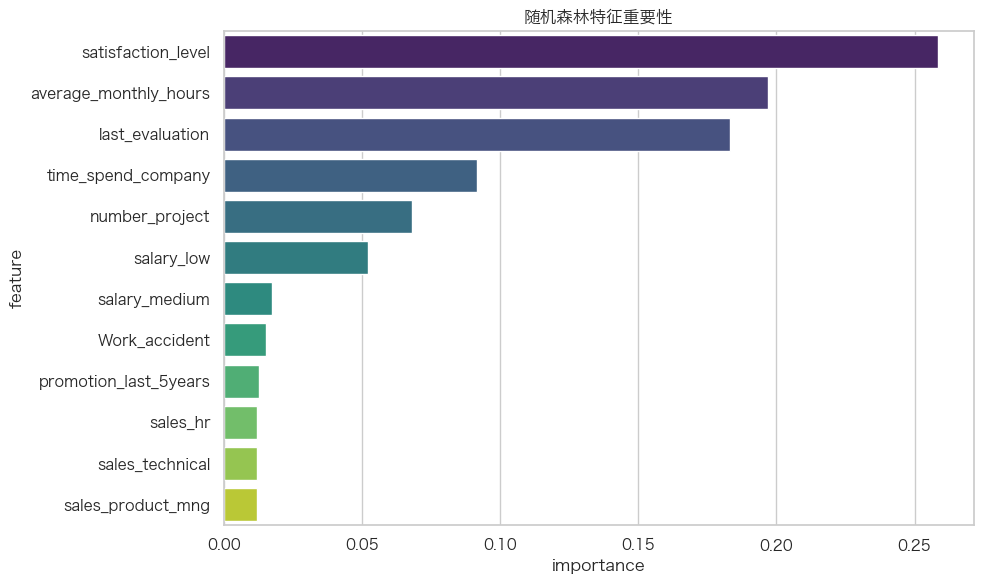

In [96]:
# 获取特征名顺序
num_features = numerical_features.tolist()
cat_encoder = best_rf.named_steps["preprocess"].named_transformers_["cat"].named_steps["encoder"]
cat_features = cat_encoder.get_feature_names_out(categorical_features)
feature_names = num_features + list(cat_features)

rf_model = best_rf.named_steps["model"]
importance_df = pd.DataFrame({"feature": feature_names, "importance": rf_model.feature_importances_}).sort_values(
    "importance", ascending=False)

print("特征重要性(前10):", importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(12), x="importance", y="feature", palette="viridis")
plt.title("随机森林特征重要性")
plt.tight_layout()
plt.show()


## 9. ROC 曲线对比

- 绘制逻辑回归与随机森林 ROC 曲线并标注 AUC

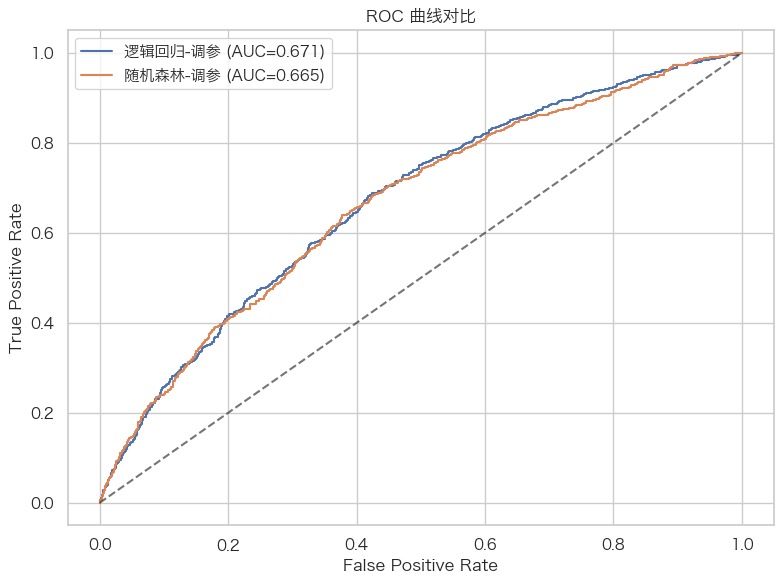

In [97]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_best_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_best_proba)
plt.figure(figsize=(8, 6))
plt.plot(log_fpr, log_tpr, label=f"逻辑回归-调参 (AUC={log_best_metrics['roc_auc']:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"随机森林-调参 (AUC={rf_best_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC 曲线对比")
plt.legend()
plt.tight_layout()
plt.show()


### 阈值与 PR 曲线：业务取舍

- 在类别不平衡场景下，Precision-Recall 曲线能更直观地看到正类检测的收益。
- 通过下方不同阈值的对比，可以选择偏向召回或精度的工作点：阈值下调时召回提高但误报增加，适合“宁可多报”场景；阈值上调则更保守，适合资源有限或误报成本高的场景。


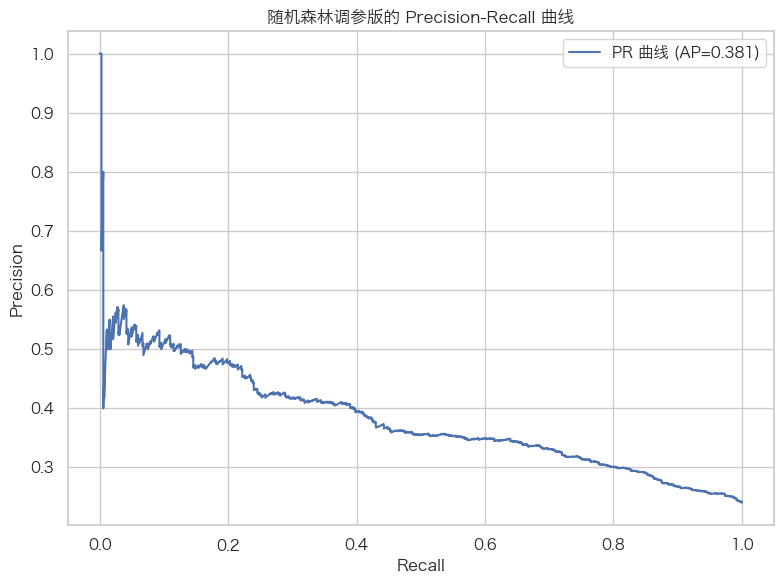

不同阈值下的业务取舍(重点关注正类召回/F1):


,recall,precision,f1,accuracy,threshold
model,,,,,
随机森林-调参@0.5,0.404993,0.394595,0.399726,0.707667,0.50
随机森林-调参@0.35,0.744799,0.319073,0.446755,0.556667,0.35


In [98]:
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(y_test, rf_best_proba)
ap = average_precision_score(y_test, rf_best_proba)

plt.figure(figsize=(8, 6))
plt.plot(rf_recall, rf_precision, label=f"PR 曲线 (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("随机森林调参版的 Precision-Recall 曲线")
plt.legend()
plt.tight_layout()
plt.show()

threshold_choices = [0.5, 0.35]
tradeoff_rows = []
for thr in threshold_choices:
    tradeoff_rows.append(summarize_metrics(f"随机森林-调参@{thr}", y_test, rf_best_proba, threshold=thr))

tradeoff_df = pd.DataFrame(tradeoff_rows).set_index("model")
print("不同阈值下的业务取舍(重点关注正类召回/F1):")
display(tradeoff_df[["recall", "precision", "f1", "accuracy", "threshold"]])


## 10. KMeans 聚类识别高风险群体

- 选取满意度、月均工时、工龄、绩效、项目数等核心特征进行标准化后 KMeans 聚类
- 按簇计算离职率并与总体对比，标记高于整体水平的簇为“高风险群体”
- 观察各簇特征轮廓，辅助制定差异化干预方案

总体离职率: 0.240
高风险簇: [0, 3]


/var/folders/wg/9ryslwv550l9xnt72kk5m_nr0000gn/T/ipykernel_44302/196199201.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_summary.reset_index(), x="cluster", y="attrition_rate", palette="flare", )


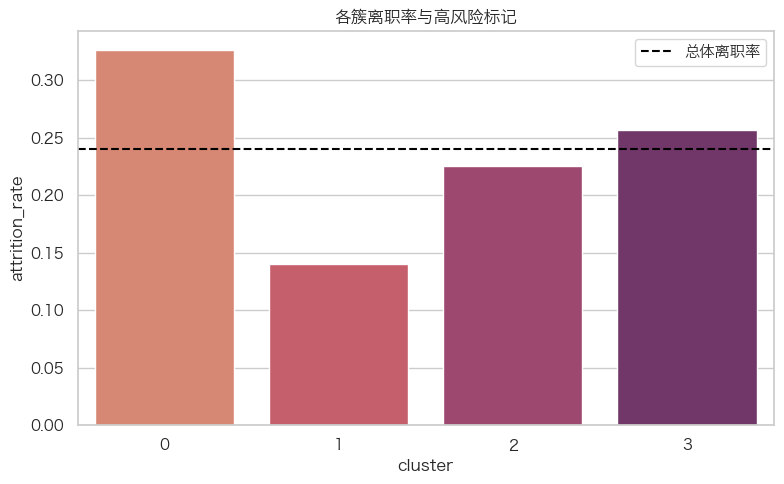

In [99]:
core_features = ["satisfaction_level", "average_monthly_hours", "time_spend_company", "last_evaluation",
    "number_project", ]

cluster_pipeline = Pipeline(
    steps=[("scaler", StandardScaler()), ("kmeans", KMeans(n_clusters=4, random_state=42, n_init=20)), ])

cluster_labels = cluster_pipeline.fit_predict(hr_df_clean[core_features])
hr_df_clean["cluster"] = cluster_labels

cluster_summary = (hr_df_clean.groupby("cluster").agg(size=("left", "size"), attrition_rate=("left", "mean"),
    satisfaction=("satisfaction_level", "mean"), hours=("average_monthly_hours", "mean"),
    tenure=("time_spend_company", "mean"), eval_score=("last_evaluation", "mean"),
    projects=("number_project", "mean"), ).sort_values("attrition_rate", ascending=False))

overall_attrition = hr_df_clean["left"].mean()
high_risk_clusters = cluster_summary[cluster_summary["attrition_rate"] > overall_attrition].index.tolist()
hr_df_clean["high_risk"] = hr_df_clean["cluster"].isin(high_risk_clusters)

print(f"总体离职率: {overall_attrition:.3f}")
print(f"高风险簇: {high_risk_clusters}")
cluster_summary.assign(高风险=cluster_summary.index.isin(high_risk_clusters))

plt.figure(figsize=(8, 5))
sns.barplot(data=cluster_summary.reset_index(), x="cluster", y="attrition_rate", palette="flare", )
plt.axhline(overall_attrition, color="black", linestyle="--", label="总体离职率")
plt.title("各簇离职率与高风险标记")
plt.ylabel("attrition_rate")
plt.legend()
plt.tight_layout()
plt.show()


## 11. 管理建议与改进方向

- 高风险簇离职率明显高于总体，普遍特征为：满意度偏低、月均工时/项目压力偏高、绩效得分与工龄处于中等偏上但缺乏晋升激励。
- 管理建议：
  - **工作负荷与排班**：针对高工时/多项目簇，控制并行项目数量、引入弹性排班或补休；监控加班预警。
  - **成长与认可**：对绩效良好但晋升/薪酬停滞的员工，建立季度晋升评审、差异化奖金与培训机会。
  - **满意度回访**：对满意度低的群体开展访谈，快速修复流程痛点（工具、沟通、职责边界），并设置 1:1 反馈循环。
  - **工龄节点关怀**：在工龄 5-7 年节点提供轮岗/职业路径规划，降低倦怠与流失意向。
- 主要影响因素归纳：满意度、工时/项目压力、绩效与晋升机会、薪资等级。改进方案聚焦于减少压力、提升认可与成长通道，并通过定期聚类刷新高风险名单，形成持续的留任监控机制。


{
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "# 项目报告（目录版）\n\n",
    "## 1.1 项目背景\n",
    "- 数据集来源于某人力资源部门的历史记录，字段包含员工满意度、月平均工时、项目数、绩效评估、是否近期晋升、部门、工资水平以及离职标记等。\n",
    "- 业务场景：管理层希望提前识别高流失风险员工，找到影响离职的关键因素，并为排班、晋升、薪酬等政策提供数据依据。\n",
    "- 数据特点：结构化表格数据，混合数值与类别变量，存在类别不平衡（离职人数占比约 24%）。\n\n",
    "## 1.2 项目目的\n",
    "1. 掌握数据清洗的基本方法和流程，确保分析指标可信。\n",
    "2. 学习使用 Python 进行数据探索性分析，理解变量分布与相关性。\n",
    "3. 掌握常用的数据可视化技术，直观展示离职特征与模型表现。\n",
    "4. 理解人力资源数据的分析思路，结合业务背景解释指标。\n",
    "5. 培养数据驱动的决策思维，用数据支持管理建议与资源分配。\n\n",
    "## 2 数据统计分析\n",
    "### 2.1 数据加载与清洗\n",
    "- 读取 HR_comma_sep.csv，统一列名并检查数据类型。\n",
    "- 缺失值与重复值检测：数据无缺失，但存在极端工时/项目数样本，采用 IQR 裁剪并保留合理区间。\n",
    "- 类别字段（部门、工资等级）做标准化命名，便于后续独热编码。\n\n",
    "### 2.2 计算关键统计指标\n",
    "- 全量与按离职与否分组的描述性统计（均值、中位数、标准差、四分位数）。\n",
    "- 核心指标示例：\n  - 满意度均值约 0.61，离职组显著低于在职组。\n  - 月均工时四分位区间集中在 200-260 小时，高于 280 的样本流失率升高。\n  - 项目数中位数为 4，项目负荷超过 6 的员工离职概率增大。\n  - 绩效评价与是否晋升与留任显著相关，近期未晋升群体流失率更高。\n\n",
    "### 2.3 数据分析\n",
    "- 类别不平衡：离职=1 占比约 24%，模型需考虑 class_weight。\n",
    "- 相关性分析：满意度与离职呈强负相关；工作时间、项目压力与离职正相关；工资等级低的部门流失率更高。\n",
    "- 部门与工资交叉分析：销售、技术等前线部门在低工资段的离职率高于后台部门；高工资段流失率整体下降。\n",
    "- 聚类探索：基于满意度、工时、工龄、绩效、项目数聚类，发现“高工时+低满意度”簇的离职率远高于总体，适合作为重点干预群体。\n\n",
    "#### 2.3.1 可视化要点\n",
    "- 箱线图：展示满意度、工时在离职/在职组的分布差异。\n",
    "- 直方图与 KDE：查看满意度、工时、绩效的整体分布及长尾情况。\n",
    "- 相关系数热力图：识别多重共线性与重要数值特征。\n",
    "- ROC/PR 曲线：对比逻辑回归与随机森林在不平衡数据上的表现。\n\n",
    "## 3 分析结论\n",
    "- 主要驱动因素：满意度、月均工时与项目压力、工资等级、近期晋升情况、绩效评分。满意度和工时是最强信号。\n",
    "- 管理建议：\n  - 控制工时与项目并行度，设置加班预警与弹性排班。\n  - 对绩效良好但缺乏晋升/加薪的员工提供成长与认可通道。\n  - 针对低满意度群体开展访谈与流程修复，定期跟踪满意度变化。\n  - 对高风险聚类人群优先采取干预，建立持续更新的风险名单。\n- 模型表现：随机森林（含 class_weight）在召回与 F1 上优于逻辑回归，适合用于流失预警；逻辑回归解释性强，可用于高层沟通。\n"
   ]
  },